Dataset Shape: (7043, 21)

Dataset Preview:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stre

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6834 - loss: 0.6125 - val_accuracy: 0.7640 - val_loss: 0.4532
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7690 - loss: 0.4762 - val_accuracy: 0.7640 - val_loss: 0.4511
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7730 - loss: 0.4654 - val_accuracy: 0.7746 - val_loss: 0.4496
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7777 - loss: 0.4513 - val_accuracy: 0.7737 - val_loss: 0.4462
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7830 - loss: 0.4547 - val_accuracy: 0.7791 - val_loss: 0.4464
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7932 - loss: 0.4370 - val_accuracy: 0.7782 - val_loss: 0.4463
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7970 - loss: 0.4336 - val_accuracy: 0.7711 - val_loss: 0.4460
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7923 - loss: 0.4324 - val_accuracy: 0.

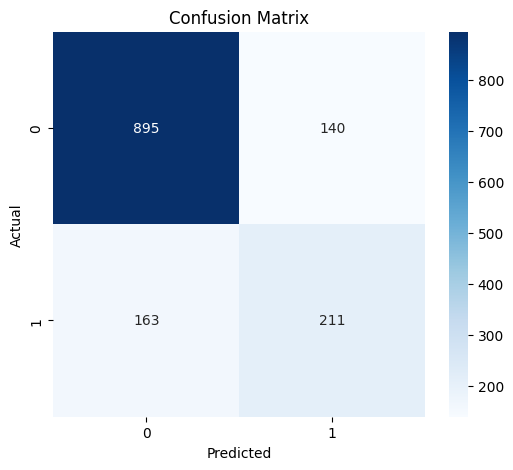

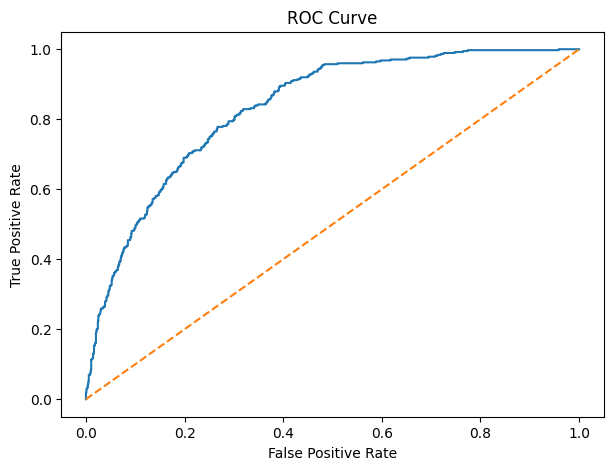

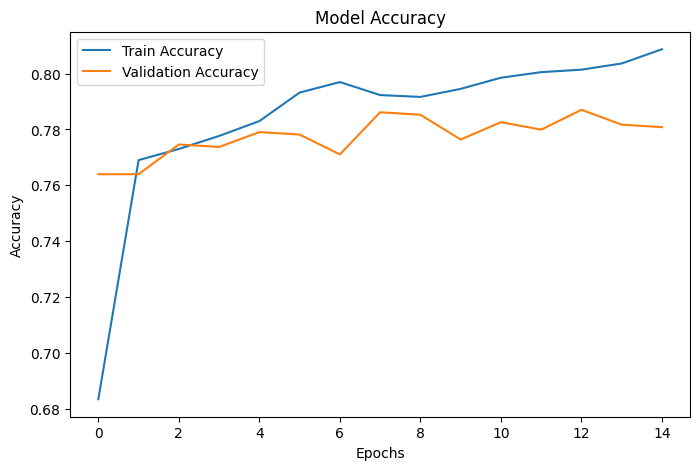

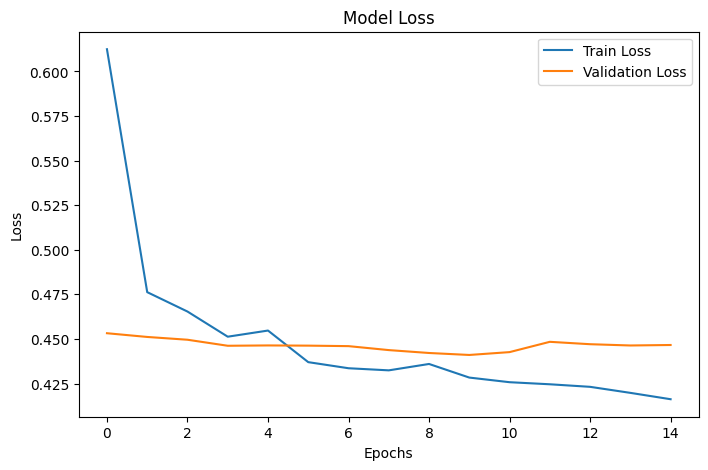

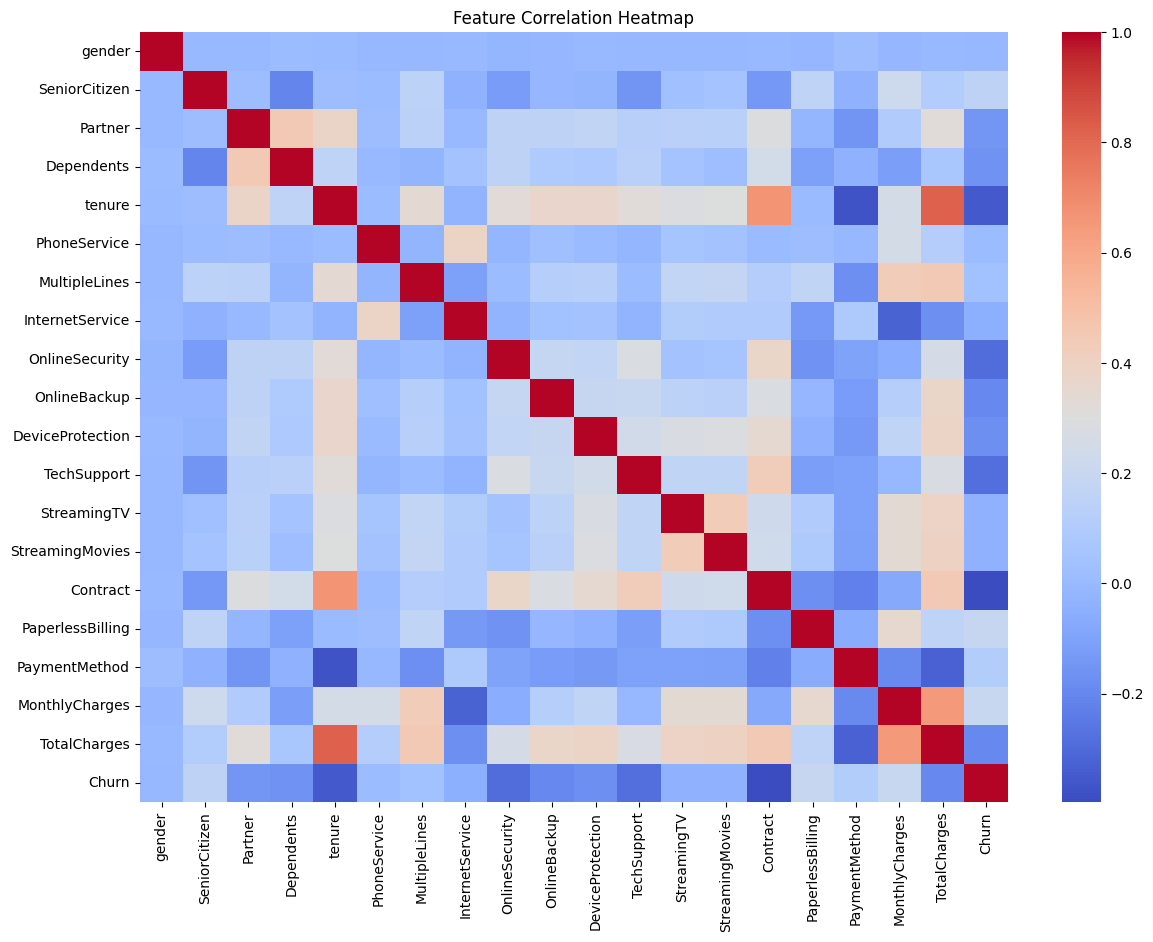


FINAL CONCLUSION
ANN model successfully trained for Customer Churn Prediction.
Final Test Accuracy: 78.50%
ROC-AUC Score: 0.8332
Deep Learning model evaluation completed.


In [3]:
# =========================================================
# CUSTOMER CHURN PREDICTION USING ANN (DEEP LEARNING)
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)

print("\nDataset Preview:")
print(df.head())

# =========================================================
# DATA PREPROCESSING
# =========================================================

# Remove spaces from column names

df.columns = df.columns.str.strip()

# Remove unnecessary column

if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

print("\nMissing Values:")
print(df.isnull().sum())

# Replace blank spaces with NaN

df.replace(" ", np.nan, inplace=True)

# Convert TotalCharges to numeric if present

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(
        df['TotalCharges'],
        errors='coerce'
    )

# Separate categorical & numerical columns

categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

# Fill numerical missing values

num_imputer = SimpleImputer(strategy='mean')

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Fill categorical missing values

cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# =========================================================
# ENCODE CATEGORICAL VARIABLES
# =========================================================

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# =========================================================
# FEATURES & TARGET
# =========================================================

X = df.drop('Churn', axis=1)

y = df['Churn']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# =========================================================
# BUILD ANN MODEL
# =========================================================

model = Sequential()

# Hidden Layer 1

model.add(
    Dense(
        units=128,
        activation='relu',
        kernel_initializer=HeNormal(),
        input_dim=X_train.shape[1]
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# Hidden Layer 2

model.add(
    Dense(
        units=64,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(Dropout(0.3))

# Hidden Layer 3

model.add(
    Dense(
        units=32,
        activation='relu'
    )
)

model.add(Dropout(0.2))

# Output Layer

model.add(
    Dense(
        units=1,
        activation='sigmoid'
    )
)

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# EARLY STOPPING
# =========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# =========================================================
# TRAIN MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# MODEL EVALUATION
# =========================================================

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"Test Accuracy: {accuracy*100:.2f}%")

# =========================================================
# PREDICTIONS
# =========================================================

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# =========================================================
# ROC-AUC SCORE
# =========================================================

roc_score = roc_auc_score(y_test, y_pred_prob)

print(f"ROC-AUC Score: {roc_score:.4f}")

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================================================
# ROC CURVE
# =========================================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# =========================================================
# ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend([
    'Train Accuracy',
    'Validation Accuracy'
])

plt.show()

# =========================================================
# LOSS GRAPH
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend([
    'Train Loss',
    'Validation Loss'
])

plt.show()

# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# =========================================================
# FINAL CONCLUSION
# =========================================================

print("\n===================================")
print("FINAL CONCLUSION")
print("===================================")

print("ANN model successfully trained for Customer Churn Prediction.")

print(f"Final Test Accuracy: {accuracy*100:.2f}%")

print(f"ROC-AUC Score: {roc_score:.4f}")

print("Deep Learning model evaluation completed.")